# Tugas Praktikum 2: Praproses Data

Nama : Ahmad Zaki Fauzan Nabil
NRP : 5054251044

## 1. Unduh dan Import Dataset
import library yang dibutuhkan dan memuat dataset `train.csv`.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [16]:
# Memuat dataset
df = pd.read_csv('train.csv')

# Menampilkan 5 baris pertama
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
# Menampilkan dimensi dataset (baris, kolom)
df.shape

(1460, 81)

In [18]:
# Menampilkan informasi dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 2. Pembersihan Data
memeriksa nilai yang hilang, menghapus atribut dengan nilai hilang > 50%, dan menangani nilai hilang sisanya.

In [5]:
# Menghitung persentase nilai yang hilang pada tiap kolom
missing_percentage = df.isnull().mean() * 100

# Menampilkan 20 atribut dengan nilai hilang tertinggi
missing_percentage.sort_values(ascending=False).head(20)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageQual       5.547945
GarageFinish     5.547945
GarageType       5.547945
GarageYrBlt      5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtCond         2.534247
BsmtQual         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
Condition2       0.000000
dtype: float64

In [6]:
# Menghapus kolom dengan proporsi nilai hilang lebih dari 50%
threshold = 50
cols_to_drop = missing_percentage[missing_percentage > threshold].index
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Kolom yang dihapus: {list(cols_to_drop)}")
print(f"Dimensi data setelah penghapusan: {df_cleaned.shape}")

Kolom yang dihapus: ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
Dimensi data setelah penghapusan: (1460, 76)


Langkah selanjutnya adalah menangani nilai hilang pada sisa atribut. Pada atribut numerik, pengisian nilai hilang menggunakan **median** (karena lebih tahan terhadap keberadaan outlier dibandingkan mean). Sedangkan untuk atribut kategoris, pengisian menggunakan **modus** (nilai yang paling sering muncul).

In [7]:
# Memisahkan atribut numerik dan kategoris
num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

# Mengisi nilai hilang pada atribut numerik dengan median
for col in num_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Mengisi nilai hilang pada atribut kategoris dengan modus
for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# Memastikan tidak ada lagi nilai yang hilang
print(f"Total nilai hilang yang tersisa: {df_cleaned.isnull().sum().sum()}")

Total nilai hilang yang tersisa: 0


## 3. Deteksi dan Penanganan Outlier
Deteksi outlier dilakukan menggunakan visualisasi **boxplot** pada beberapa atribut numerik, seperti `SalePrice`, `GrLivArea`, `TotalBsmtSF`, dan `LotArea`. 

Penanganan outlier dapat dilakukan dengan menghapus data ekstrem atau menyesuaikan nilainya (*Winsorization/Capping*). Pada praktikum ini, penyesuaian nilai (*capping*) dipilih agar tidak membuang terlalu banyak baris observasi dari dataset.

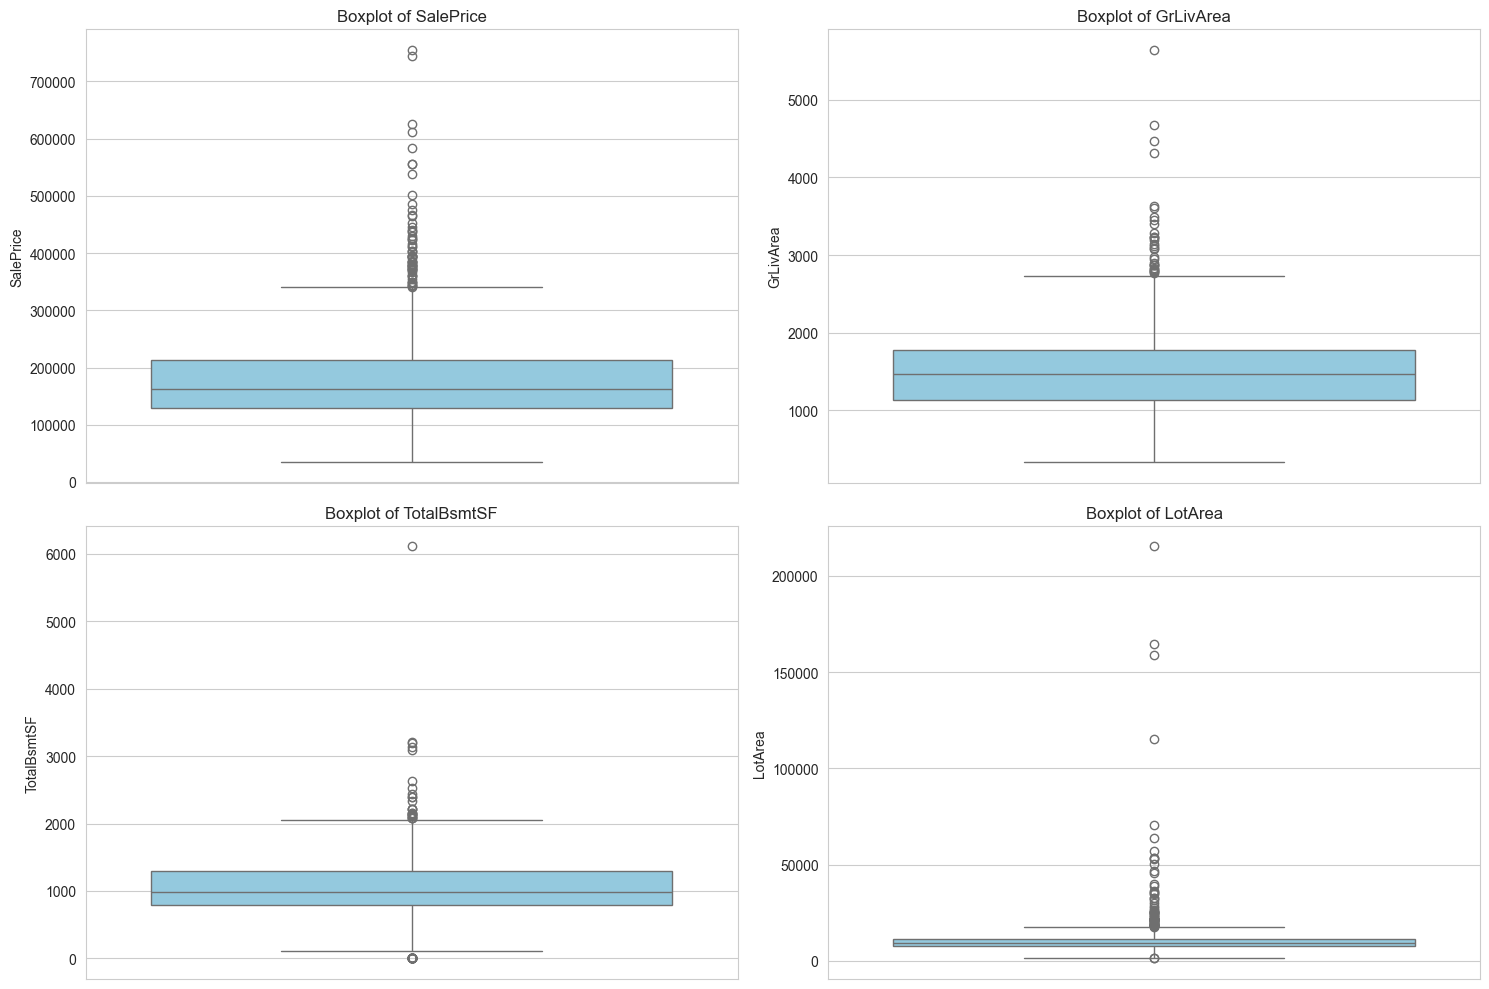

In [8]:
# Menampilkan Boxplot untuk mendeteksi outlier pada fitur penting
features_to_check = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_cleaned[feature], color='skyblue')
    plt.title(f'Boxplot of {feature}')
    plt.tight_layout()
plt.show()

Berdasarkan visualisasi boxplot di atas, terdapat banyak pencilan (outlier), terutama pada bagian atas (upper bound). Penanganan outlier dilakukan menggunakan metode batas **IQR (Interquartile Range)** untuk melakukan *capping* (menyesuaikan nilai outlier ke batas wajar) sehingga tidak perlu menghapus baris data.

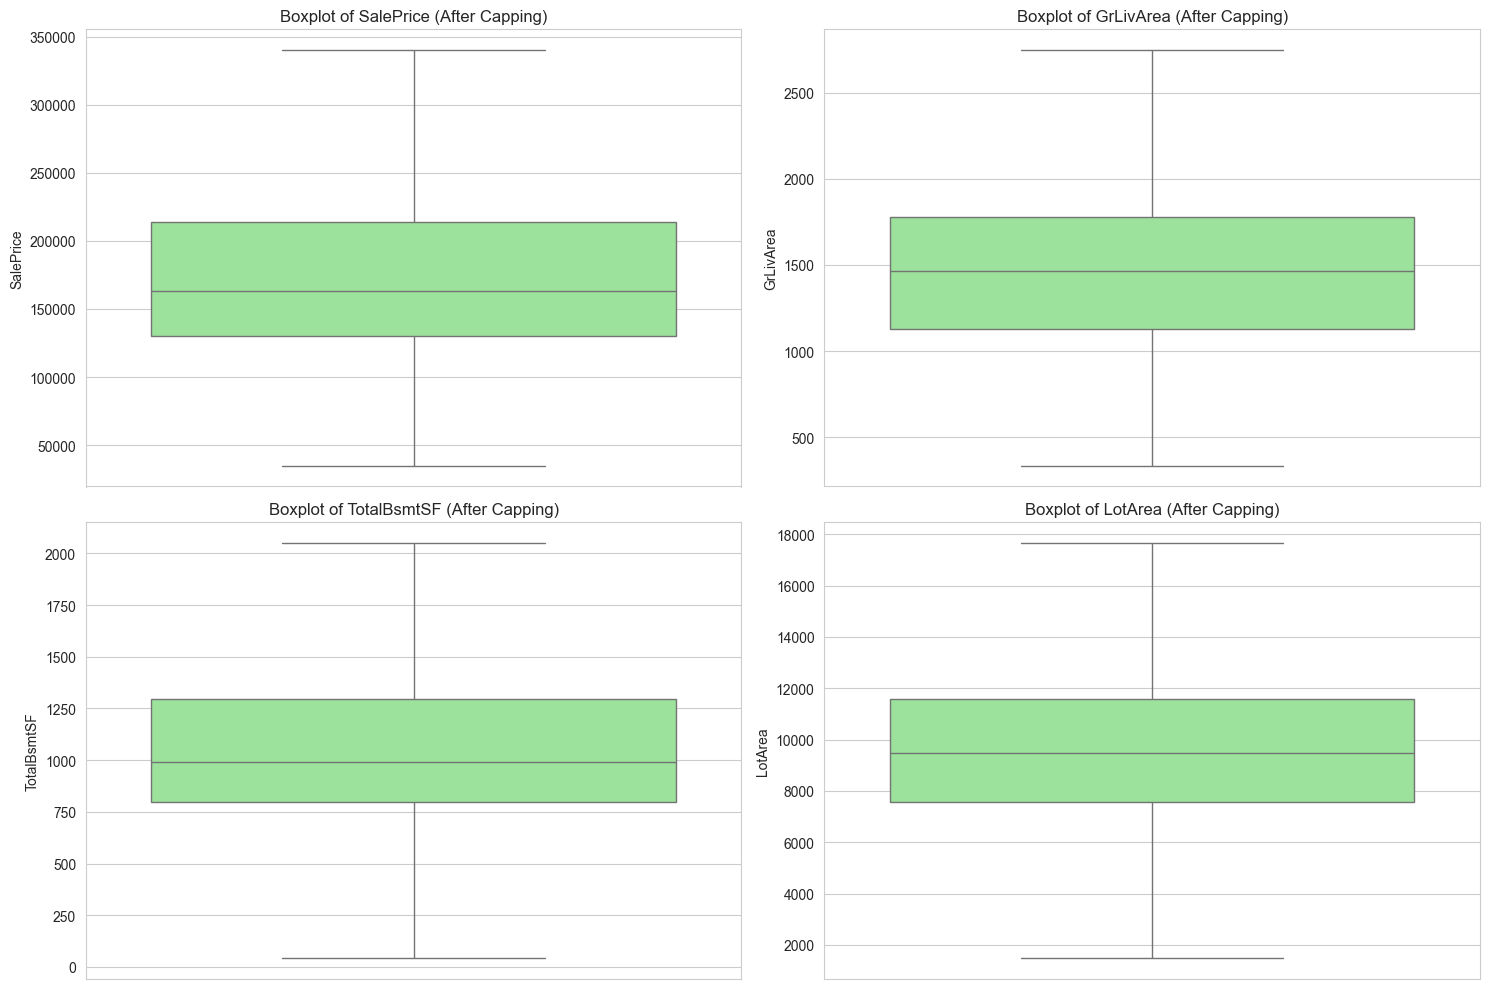

In [9]:
# Fungsi untuk melakukan clipping (capping) outlier berdasarkan metode IQR
def cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Clip nilai yang di luar batas IQR
    df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

# Menerapkan pada beberapa kolom dengan outlier tinggi
for feature in num_cols:
    df_cleaned = cap_outliers(df_cleaned, feature)

# Memeriksa kembali setelah penyesuaian (capping)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_check, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df_cleaned[feature], color='lightgreen')
    plt.title(f'Boxplot of {feature} (After Capping)')
    plt.tight_layout()
plt.show()

## 4. Transformasi Data
Tahapan ini meliputi proses normalisasi pada atribut numerik agar skalanya seragam, serta penerapan *one-hot encoding* untuk atribut kategoris.

In [10]:
from sklearn.preprocessing import StandardScaler

# Normalisasi/Standarisasi menggunakan StandardScaler (Z-score normalization)
scaler = StandardScaler()
df_transformed = df_cleaned.copy()

# Kolom 'Id' (identifier) dan 'SalePrice' (target variabel) tidak perlu distandarisasi.
num_cols_to_scale = [col for col in num_cols if col not in ['Id', 'SalePrice']]

df_transformed[num_cols_to_scale] = scaler.fit_transform(df_transformed[num_cols_to_scale])

# Menampilkan hasil normalisasi
df_transformed[num_cols_to_scale].head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,0.131067,-0.237456,-0.333244,0.652644,-0.564161,1.053246,0.878668,0.795643,0.614224,0.0,...,0.373509,-0.787243,0.350520,0.0,0.0,0.0,0.0,0.0,-1.599111,0.138777
1,-0.935733,0.633321,-0.013189,-0.073068,2.030907,0.156179,-0.429577,-0.667353,1.242296,0.0,...,-0.051541,1.768105,-0.811747,0.0,0.0,0.0,0.0,0.0,-0.489110,-0.614439
2,0.131067,-0.063300,0.446022,0.652644,-0.564161,0.986797,0.830215,0.541858,0.106224,0.0,...,0.663315,-0.787243,-0.011497,0.0,0.0,0.0,0.0,0.0,0.990891,0.138777
3,0.397766,-0.527714,-0.027104,0.652644,-0.564161,-1.870528,-0.720298,-0.667353,-0.517230,0.0,...,0.827539,-0.787243,-0.144872,0.0,0.0,0.0,0.0,0.0,-1.599111,-1.367655
4,0.131067,0.865528,1.283733,1.378355,-0.564161,0.953572,0.733308,1.945140,0.496460,0.0,...,1.764579,0.859156,0.788753,0.0,0.0,0.0,0.0,0.0,2.100892,0.138777


In [11]:
# Melakukan One-Hot Encoding pada atribut kategoris
# drop_first=True digunakan untuk menghindari Dummy Variable Trap (Multikolinearitas absolut)
df_encoded = pd.get_dummies(df_transformed, columns=cat_cols, drop_first=True)

print(f"Dimensi data setelah One-Hot Encoding: {df_encoded.shape}")
df_encoded.head()

Dimensi data setelah One-Hot Encoding: (1460, 235)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,0.131067,-0.237456,-0.333244,0.652644,-0.564161,1.053246,0.878668,0.795643,0.614224,...,False,False,False,False,True,False,False,False,True,False
1,2,-0.935733,0.633321,-0.013189,-0.073068,2.030907,0.156179,-0.429577,-0.667353,1.242296,...,False,False,False,False,True,False,False,False,True,False
2,3,0.131067,-0.063300,0.446022,0.652644,-0.564161,0.986797,0.830215,0.541858,0.106224,...,False,False,False,False,True,False,False,False,True,False
3,4,0.397766,-0.527714,-0.027104,0.652644,-0.564161,-1.870528,-0.720298,-0.667353,-0.517230,...,False,False,False,False,True,False,False,False,False,False
4,5,0.131067,0.865528,1.283733,1.378355,-0.564161,0.953572,0.733308,1.945140,0.496460,...,False,False,False,False,True,False,False,False,True,False


## 5. Reduksi Dimensi
Reduksi dimensi diawali dengan analisis korelasi untuk membuang atribut yang sangat berkorelasi kuat (mengatasi multikolinearitas). Selanjutnya, metode **PCA (Principal Component Analysis)** diterapkan untuk mengurangi dimensi keseluruhan.

In [12]:
# Menghitung matriks korelasi hanya untuk atribut numerik yang sudah diproses
corr_matrix = df_transformed[num_cols_to_scale].corr().abs()

# Menemukan fitur yang memiliki korelasi tinggi (misal > 0.8)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"Fitur yang sangat berkorelasi dan akan dibuang: {to_drop}")

# Membuang fitur yang sangat berkorelasi pada df_encoded
df_reduced = df_encoded.drop(columns=to_drop)
print(f"Dimensi data setelah menghapus fitur yang berkorelasi: {df_reduced.shape}")

Fitur yang sangat berkorelasi dan akan dibuang: ['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea']
Dimensi data setelah menghapus fitur yang berkorelasi: (1460, 232)


In [13]:
from sklearn.decomposition import PCA

# Memisahkan fitur (X) dan target (y). Kolom Id juga dihapus.
X = df_reduced.drop(columns=['Id', 'SalePrice'])
y = df_reduced['SalePrice']

# PCA sensitif terhadap skala, namun datanya sudah dinormalisasi dan di-encode sebelumnya.
# Menentukan komponen PCA untuk mempertahankan 95% variance dari data asli
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Dimensi asli X: {X.shape}")
print(f"Dimensi X setelah PCA: {X_pca.shape}")
print(f"Jumlah komponen utama (Principal Components) yang diperlukan untuk mempertahankan 95% informasi: {pca.n_components_}")

Dimensi asli X: (1460, 230)
Dimensi X setelah PCA: (1460, 65)
Jumlah komponen utama (Principal Components) yang diperlukan untuk mempertahankan 95% informasi: 65


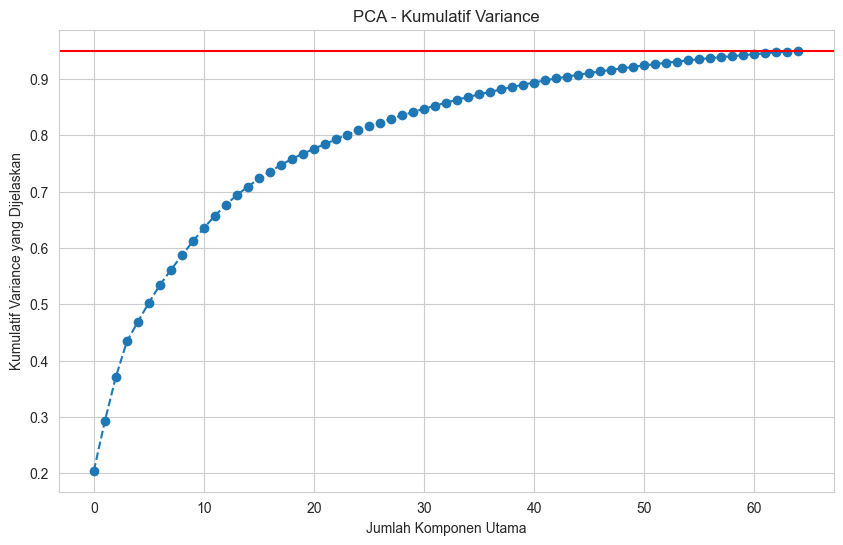

In [14]:
# Visualisasi variance yang dijelaskan oleh komponen utama
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Jumlah Komponen Utama')
plt.ylabel('Kumulatif Variance yang Dijelaskan')
plt.title('PCA - Kumulatif Variance')
plt.axhline(y=0.95, color='r', linestyle='-')
plt.grid(True)
plt.show()

### Kesimpulan
Proses persiapan data telah selesai:
1. **Pembersihan Data:** Atribut dengan nilai hilang di atas 50% dibuang, sisanya diisi dengan *median* untuk numerik dan *modus* untuk kategorikal.
2. **Penanganan Outlier:** Mendeteksi dengan boxplot dan menanganinya menggunakan metode *IQR capping* (menyesuaikan batas atas & bawah) sehingga distribusi data tidak membuang data observasi penting.
3. **Transformasi Data:** Data numerik distandarisasi (Z-score), dan data kategorikal di-*encode* dengan *One-Hot Encoding*.
4. **Reduksi Dimensi:** Atribut dengan korelasi tinggi (>0.8) dihapus. Terakhir, dimensi fitur direduksi menggunakan **PCA**, yang secara efisien mampu mempertahankan 95% varians data sekaligus memampatkan jumlah fitur.